In [1]:
import pandas as pd

delhi = pd.read_csv("../outputs/delhi_merged_daily.csv")
mumbai = pd.read_csv("../outputs/mumbai_merged_daily.csv")
bengaluru = pd.read_csv("../outputs/bengaluru_merged_daily.csv")
chennai = pd.read_csv("../outputs/chennai_merged_daily.csv")
hyderabad = pd.read_csv("../outputs/hyderabad_merged_daily.csv")

delhi["city"] = "Delhi"
mumbai["city"] = "Mumbai"
bengaluru["city"] = "Bengaluru"
chennai["city"] = "Chennai"
hyderabad["city"] = "Hyderabad"

df_all = pd.concat(
    [delhi, mumbai, bengaluru, chennai, hyderabad],
    ignore_index=True
)

df_all["date"] = pd.to_datetime(df_all["date"], dayfirst=True)
df_all["month"] = df_all["date"].dt.month


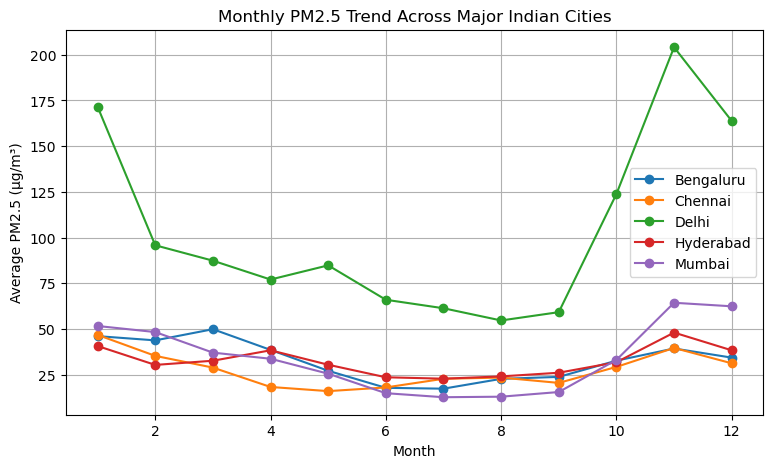

In [2]:
import matplotlib.pyplot as plt

monthly_pm25 = (
    df_all
    .groupby(["city", "month"])["PM2.5 (µg/m³)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9,5))

for city in monthly_pm25["city"].unique():
    data = monthly_pm25[monthly_pm25["city"] == city]
    plt.plot(
        data["month"],
        data["PM2.5 (µg/m³)"],
        marker="o",
        label=city
    )

plt.xlabel("Month")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("Monthly PM2.5 Trend Across Major Indian Cities")
plt.legend()
plt.grid(True)
plt.show()


<Figure size 800x500 with 0 Axes>

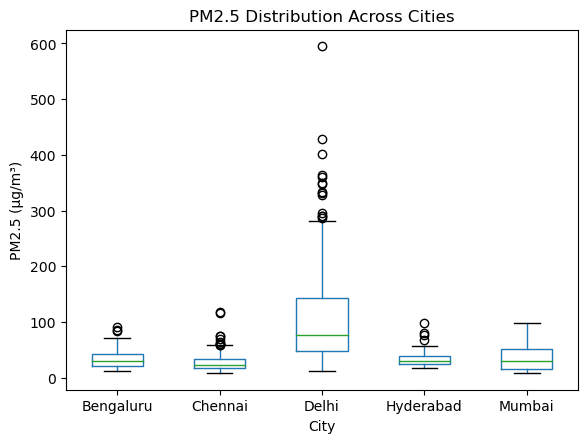

In [3]:
plt.figure(figsize=(8,5))
df_all.boxplot(
    column="PM2.5 (µg/m³)",
    by="city",
    grid=False
)
plt.title("PM2.5 Distribution Across Cities")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()


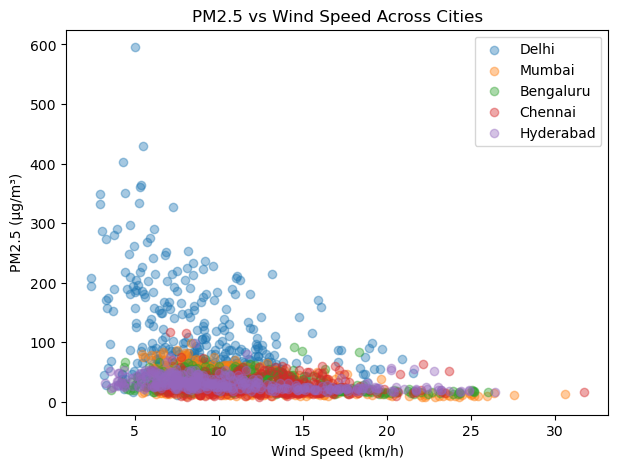

In [4]:
plt.figure(figsize=(7,5))

for city in df_all["city"].unique():
    city_data = df_all[df_all["city"] == city]
    plt.scatter(
        city_data["wind_speed_10m (km/h)"],
        city_data["PM2.5 (µg/m³)"],
        alpha=0.4,
        label=city
    )

plt.xlabel("Wind Speed (km/h)")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 vs Wind Speed Across Cities")
plt.legend()
plt.show()


In [5]:
coastal = df_all[df_all["city"].isin(["Mumbai", "Chennai"])]
inland = df_all[df_all["city"].isin(["Delhi", "Bengaluru", "Hyderabad"])]

print("Average PM2.5 (Coastal):", coastal["PM2.5 (µg/m³)"].mean())
print("Average PM2.5 (Inland):", inland["PM2.5 (µg/m³)"].mean())


Average PM2.5 (Coastal): 30.897911543799637
Average PM2.5 (Inland): 56.40683098055859


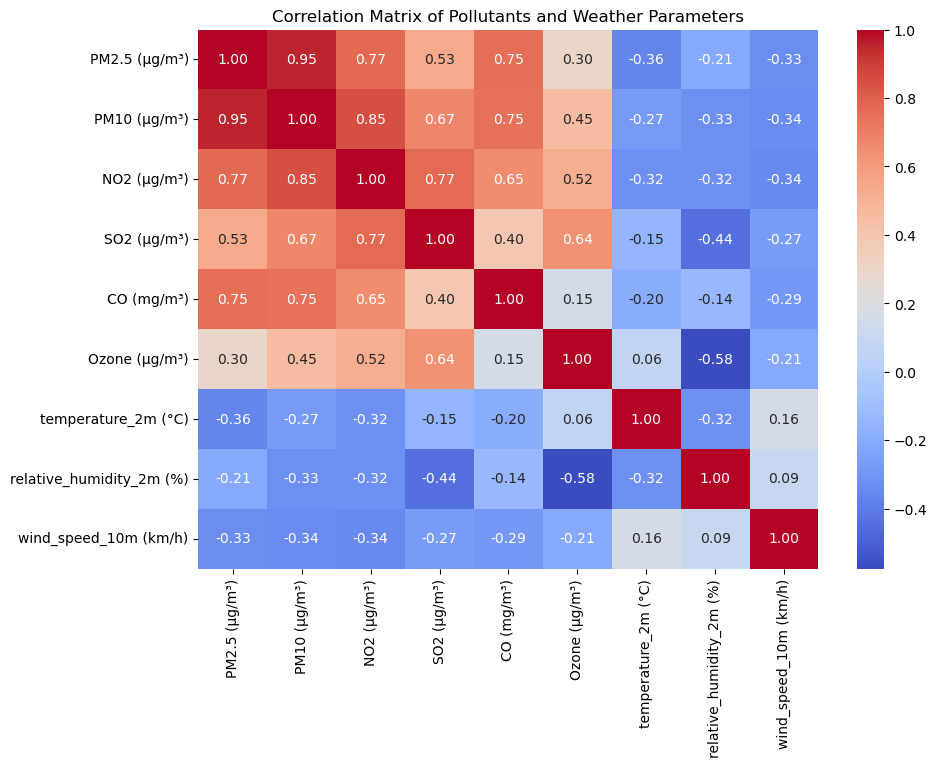

In [6]:
import seaborn as sns

features_for_corr = [
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "wind_speed_10m (km/h)"
]

plt.figure(figsize=(10,7))
sns.heatmap(
    df_all[features_for_corr].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Pollutants and Weather Parameters")
plt.show()


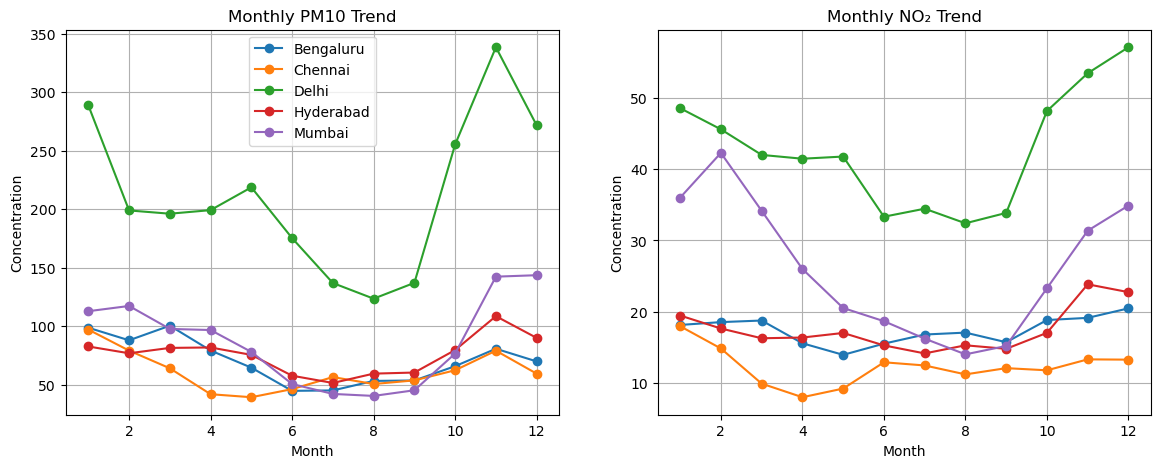

In [7]:
pollutants = ["PM10 (µg/m³)", "NO2 (µg/m³)"]

monthly_pollutants = (
    df_all
    .groupby(["city", "month"])[pollutants]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

for city in monthly_pollutants["city"].unique():
    city_data = monthly_pollutants[monthly_pollutants["city"] == city]
    axes[0].plot(city_data["month"], city_data["PM10 (µg/m³)"], marker="o", label=city)
    axes[1].plot(city_data["month"], city_data["NO2 (µg/m³)"], marker="o", label=city)

axes[0].set_title("Monthly PM10 Trend")
axes[1].set_title("Monthly NO₂ Trend")
for ax in axes:
    ax.set_xlabel("Month")
    ax.set_ylabel("Concentration")
    ax.grid(True)

axes[0].legend()
plt.show()


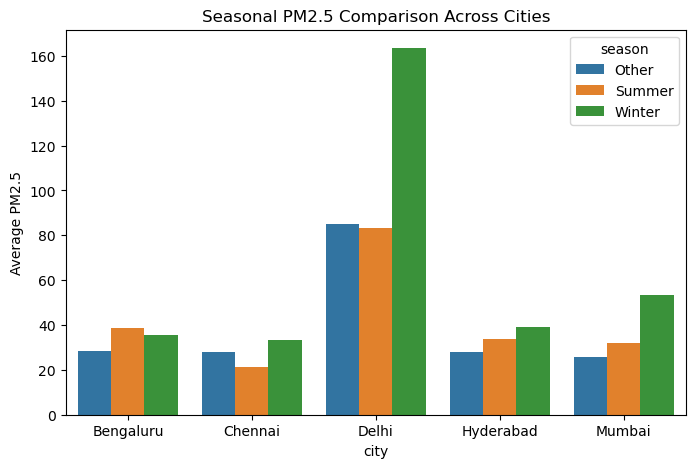

In [8]:
def season(month):
    if month in [10, 11, 12]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    else:
        return "Other"

df_all["season"] = df_all["month"].apply(season)

seasonal_pm25 = (
    df_all
    .groupby(["city", "season"])["PM2.5 (µg/m³)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=seasonal_pm25,
    x="city",
    y="PM2.5 (µg/m³)",
    hue="season"
)
plt.title("Seasonal PM2.5 Comparison Across Cities")
plt.ylabel("Average PM2.5")
plt.show()


<Figure size 800x500 with 0 Axes>

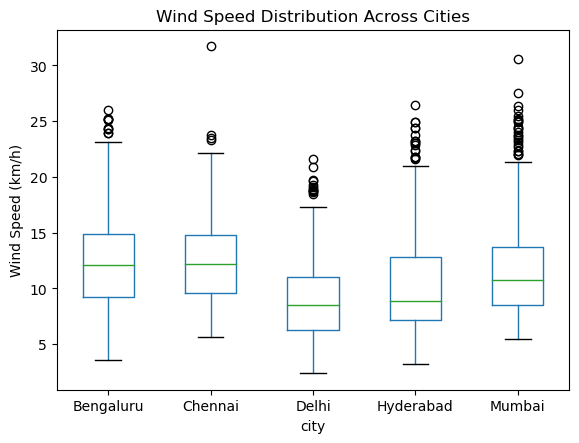

In [9]:
plt.figure(figsize=(8,5))
df_all.boxplot(
    column="wind_speed_10m (km/h)",
    by="city",
    grid=False
)
plt.title("Wind Speed Distribution Across Cities")
plt.suptitle("")
plt.ylabel("Wind Speed (km/h)")
plt.show()


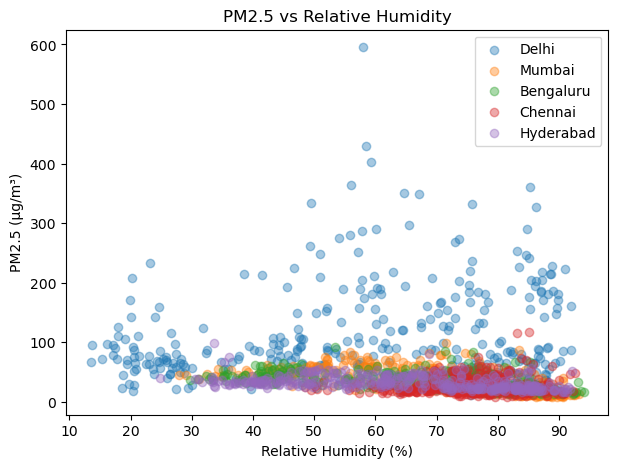

In [10]:
plt.figure(figsize=(7,5))

for city in df_all["city"].unique():
    city_data = df_all[df_all["city"] == city]
    plt.scatter(
        city_data["relative_humidity_2m (%)"],
        city_data["PM2.5 (µg/m³)"],
        alpha=0.4,
        label=city
    )

plt.xlabel("Relative Humidity (%)")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 vs Relative Humidity")
plt.legend()
plt.show()


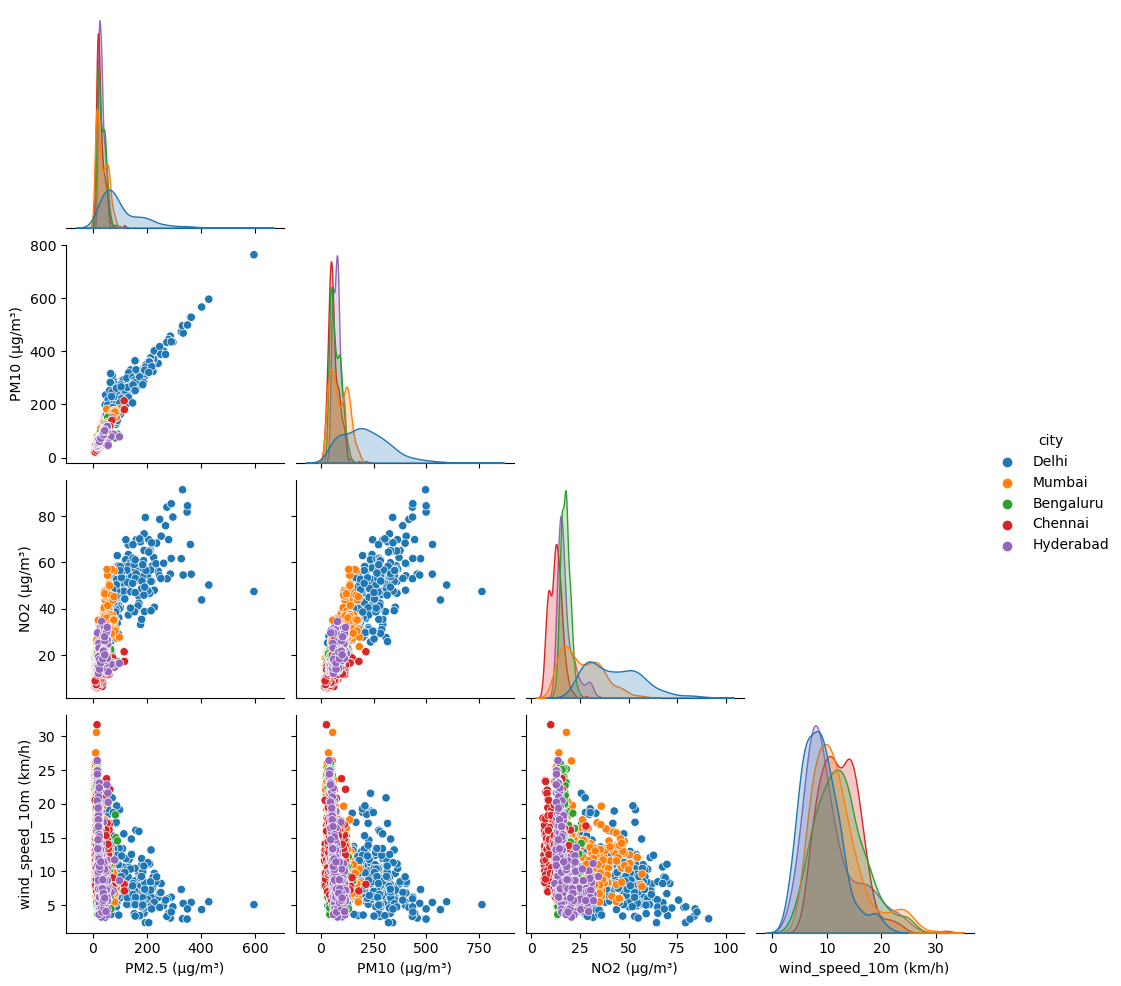

In [11]:
sns.pairplot(
    df_all,
    vars=[
        "PM2.5 (µg/m³)",
        "PM10 (µg/m³)",
        "NO2 (µg/m³)",
        "wind_speed_10m (km/h)"
    ],
    hue="city",
    corner=True
)
plt.show()
